# Dataset cleaning / filtering

In this notebook we further structure our data - filtering out unwanted information and extracting wanted one(s).

In [80]:
import pandas as pd
import re
import ast
import matplotlib.pyplot as plt
from collections import Counter

In [81]:
csv_path = "../data/GP_1750_2000_opium.csv"
df = pd.read_csv(csv_path)

In [82]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [83]:
df.columns

Index(['Etext Number', 'Type', 'Issued', 'Title', 'Language', 'LoCC',
       'Bookshelves', 'Authors', 'rights', 'Subjects', 'Read online (web)',
       'EPUB3 (E-readers incl. Send-to-Kindle)', 'EPUB (older E-readers)',
       'EPUB (no images, older E-readers)', 'Kindle',
       'Kindle (E-readers incl. Send-to-Kindle)',
       'Kindle (no images, older E-readers)', 'Plain Text UTF-8',
       'Download HTML(zip)', 'Resource Description Framework (RDF)',
       'Other Links', 'published_year', 'Opium Keywords'],
      dtype='object')

We're not gonna use all of these columns so let's just drop the ones we don't need

In [84]:
unneeded_cols = ['rights', 'Read online (web)', 'EPUB3 (E-readers incl. Send-to-Kindle)', 'EPUB (older E-readers)',
       'EPUB (no images, older E-readers)', 'Kindle',
       'Kindle (E-readers incl. Send-to-Kindle)',
       'Kindle (no images, older E-readers)', 'Plain Text UTF-8',
       'Download HTML(zip)', 'Resource Description Framework (RDF)',
       'Other Links']
df = df.drop(columns=unneeded_cols)

In [85]:
print(f"Dataset shape: {df.shape}")
df.head(5)

Dataset shape: (6776, 11)


,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,Subjects,published_year,Opium Keywords
0,16,Text,2008-06-25,Peter Pan,en,PR; PZ,Children's Literature; Movie Books; Browsing: Children & Young Adult Reading; Browsing: Literature; Browsing: Science-Fiction & Fantasy; Browsing: Fiction,"Barrie, J. M. (James Matthew)",Peter Pan (Fictitious character) -- Fiction ; Fairies -- Fiction ; Fantasy literature ; PZ ; Never-Never Land (Imaginary place) -- Fiction ; Pirates -- Fiction ; PR,1800,['heroin']
1,22,Text,1991-12-01,Roget's Thesaurus,en,PE,Reference; Browsing: Encyclopedias/Dictionaries/Reference; Browsing: Language & Communication; Browsing: Literature,"Roget, Peter Mark",English language -- Synonyms and antonyms ; PE,1805,"['opium', 'morphine', 'poppy', 'nepenthe', 'laudanum', 'paregoric', 'heroin', 'narcotic', 'soporific', 'anodyne']"
2,24,Text,2008-06-27,O Pioneers!,en,PS,Browsing: Culture/Civilization/Society; Browsing: History - American; Browsing: Literature; Browsing: Fiction,"Cather, Willa",Swedish Americans -- Fiction ; Frontier and pioneer life -- Nebraska -- Fiction ; Women immigrants -- Fiction ; Nebraska -- Fiction ; Women farmers -- Fiction ; Farm life -- Fiction ; PS ; Historical fiction ; Siblings -- Fiction ; Women pioneers -- Fiction ; Domestic fiction,1855,['poppy']
3,27,Text,1992-03-01,Far from the Madding Crowd,en,PR,Browsing: Culture/Civilization/Society; Browsing: Literature; Browsing: Fiction,"Hardy, Thomas",Triangles (Interpersonal relations) -- Fiction ; Love stories ; Pastoral fiction ; Women farmers -- Fiction ; Farm life -- Fiction ; Wessex (England) -- Fiction ; Didactic fiction ; PR,1838,['heroin']
4,33,Text,1992-06-01,The Scarlet Letter,en,PS,Harvard Classics; Movie Books; Browsing: Culture/Civilization/Society; Browsing: History - American; Browsing: Literature; Browsing: Fiction,"Hawthorne, Nathaniel","Revenge -- Fiction ; Women immigrants -- Fiction ; Illegitimate children -- Fiction ; Triangles (Interpersonal relations) -- Fiction ; Adultery -- Fiction ; Boston (Mass.) -- History -- Colonial period, ca. 1600-1775 -- Fiction ; Married women -- Fiction ; Psychological fiction ; Clergy -- Fiction ; PS ; Puritans -- Fiction ; Historical fiction",1822,['nepenthe']


From here we observe 3 interrelated columns:
* `LoCC`, which refers to the [Library of Congress Classification](https://www.loc.gov/catdir/cpso/lcc.html) - classifying books into classes and subclasses (e.g class "P" is "Language and Literature", "PR" is its subclass for English and "PS" for American)
* `Bookshelves`, which are curated thematic collections by Project Gutenberg itself. It has explicit, clean genre labels like "Science Fiction", "Mystery/Crime", "Children's Literature"
* `Subjects`, which includes a mix of themes including the LoCC (e.g "PR"), genre ("... -- Fiction") and other finer-grained topics (like theme - "Adultery", place - "Boston", or time - "Colonial period" etc) (separated by ";" and then by "--")

--> We can use `LoCC` to broadly categorize the book type, `Bookshelves` to extract book genre and `Subjects` to extract finer themes/topics

(Heads up - it's a bit messy because they're all connected to each other. The first (LoCC) was a standard system from Library of Congress Classification, the second two are annotations from Project Gutenberg itself that derives from a mix of volunteer input (human contributors that digitize, proofread, and categorize the books) and other standard systems like LCSH (Library of Congress Subject Headings), LoCC itself, etc -> we have to entangle this a bit)

### LoCC

In [87]:
df['LoCC'].str.split(';').explode().str.strip().value_counts().head(20)

LoCC
PR      2004
PS      1839
PZ       778
PQ       311
DA       136
PN       114
DS       106
PT        67
HQ        64
D501      55
BF        48
PA        46
PG        46
QH        44
DC        43
D         37
E151      36
QL        33
CT        32
DG        30
Name: count, dtype: int64

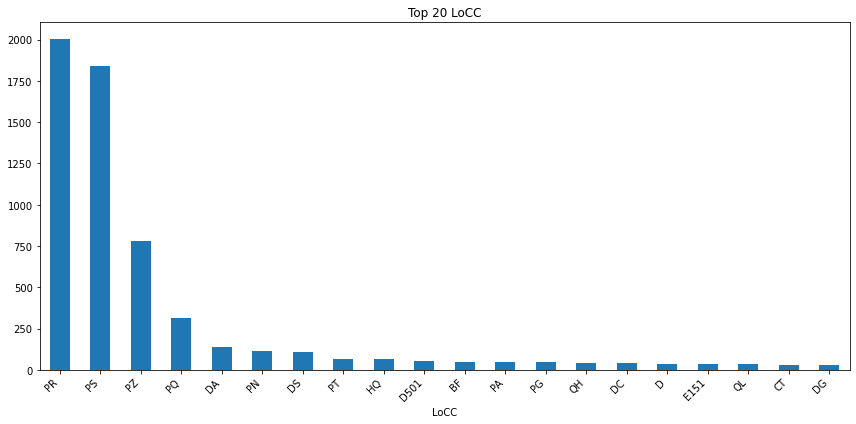

In [88]:
ax = df['LoCC'].str.split(';').explode().str.strip().value_counts().head(20).plot(
    kind="bar", figsize=(12,6), title="Top 20 LoCC"
)
ax.tick_params(axis="x", rotation=45)
plt.xticks(ha="right")
plt.tight_layout()

The majority of these books belong to PR, PS, PZ and PQ, which are subclasses of P (Language and Literature), representing English, American, Fiction & juvenile belles lettres, and French - Italian - Spanish -Portuguese literature, respectively.

A short overview of the high-level classes of LoCC (only showing the ones that were included in the above example - here we refer to the first letter of the extracted text e.g subclasses PR, PS, PZ belongs to class P; DA, D501 belongs to class D) ([source](https://www.loc.gov/catdir/cpso/lcco/)):
* P: Language and Literature
* D: World History and History of Europe, Asia, Africa, Australia, New Zealand, etc
* H: Social Sciences
* B: Philosophy, Psychology, Religion
* Q: Science
* C: Auxiliary Sciences of History

Probably we'll focus on P only? Since then we can actually detect male and female "character" thus exploring this gendered depiction with more focus

## Genre Extraction from `Bookshelves`

Note that "genre" are a bit lower level (more granular) the LoCC but still have quite some overlap - e.g we will see that it has "Literature" but also "Fiction" and "Humour" (which are subcategories of Literature??)

In [89]:
def extract_genres(bookshelves: str) -> list[str]:
    if pd.isna(bookshelves):
        return []
    
    genres = []
    
    for entry in bookshelves.split(";"):
        entry = entry.strip()
        
        # Remove prefix like "Browsing: X"
        if ":" in entry:
            _, entry = entry.split(":", 1)
            entry = entry.strip()
        
        # Keep only main genre (before " - " e.g "Science - General")
        if " - " in entry:
            entry = entry.split(" - ", 1)[0].strip()
        
        if entry:
            genres.append(entry)
    
    return list(set(genres)) # remove dups

df["Genres"] = df["Bookshelves"].apply(extract_genres)
df["Genres"].sample(20)

5176                                                       [Sociology, Psychiatry/Psychology]
1318                                 [Literature, Science-Fiction & Fantasy, Science Fiction]
1829                                      [Culture/Civilization/Society, Fiction, Literature]
3971                                               [Biographies, Music, Performing Arts/Film]
5113                                               [Travel & Geography, Biographies, History]
3467                                  [Law & Criminology, Fiction, Crime/Mystery, Literature]
2006                                  [Culture/Civilization/Society, Biographies, Literature]
3575                                      [Culture/Civilization/Society, Fiction, Literature]
2728                                                           [Fiction, History, Literature]
3250                                                                                [History]
4785                                                        

In [90]:
df["Genres"].explode().value_counts()

Genres
Literature                                                 4217
Fiction                                                    4006
Culture/Civilization/Society                               2315
History                                                    1734
Children & Young Adult Reading                              784
Travel & Geography                                          599
Biographies                                                 413
Crime/Mystery                                               335
Poetry                                                      296
Religion/Spirituality/Paranormal                            295
Philosophy & Ethics                                         259
Science-Fiction & Fantasy                                   241
Science                                                     187
Humour                                                      184
Politics                                                    147
Psychiatry/Psychology            

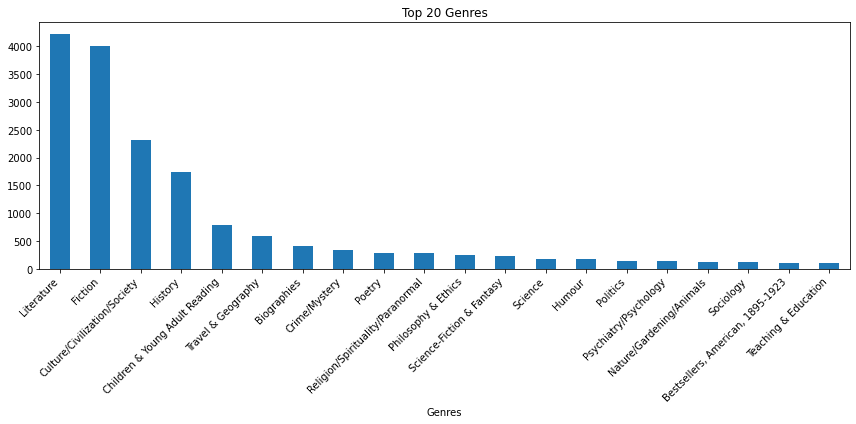

In [91]:
ax = df["Genres"].explode().value_counts().head(20).plot(
    kind="bar", figsize=(12,6), title="Top 20 Genres"
)

ax.tick_params(axis="x", rotation=45)
plt.xticks(ha="right")
plt.tight_layout()

### Theme Extraction from `Subjects`

Subjects are even more messy because it contains both LoCC and genre among other things

In [20]:
df.Subjects.sample(20)

4709                                                                                                                                                                                                        Rome (Italy) -- History -- 476-1420 -- Fiction ; Holy Roman Empire -- History -- Otto III, 983-1002 -- Fiction ; PS ; Otto III, Holy Roman Emperor, 980-1002 -- Fiction
2371                                                                                                                                                                                                                                                                                                                                   Actors ; Actresses ; PN ; Theater -- History
1658                                                                                                                                                                                                                                                            

In [92]:
# Extract all LoCCs and genre to filter those overlapping with these 2 attributes
loccs = df['LoCC'].str.split(';').explode().str.strip().unique()
genres = df['Genres'].explode().str.strip().str.lower().unique()

def extract_themes(subjects: str) -> list[str]:
    if pd.isna(subjects):
        return []
    
    themes = []
    for entry in subjects.split(";"):
        entry = entry.strip()

        # Skip LoCC or genres
        if entry in loccs or entry.lower() in genres:
            continue
        
        if "--" in entry:
            # Extract the themes from the subjects, still excluding genres if any
            # e.g. "Revenge -- Fiction" -> ["Revenge"]
            # e.g Great Britain -- Social conditions -- 19th century -> ["Great Britain", "Social conditions", "19th century"]
            subs = [s.strip() for s in entry.split("--") if s.strip() and s.strip().lower() not in genres]
            
            if subs:
                themes = themes + subs
        
        else:
            # Standalone labels — keep as-is
            themes.append(entry)
        
    return list(set(themes))


df["Themes"] = df["Subjects"].apply(extract_themes)

In [ ]:
df["Themes"].sample(20)

5287                  [Trusts, Industrial, Social conditions, 1865-1918, Economic conditions, Working class]
1961                                                                                 [Saving and investment]
6341                                                                  [Space warfare, Life on other planets]
2809                                                                                                      []
2296                                                   [Freedom of the press, Corrupt practices, Journalism]
2750                                                                          [Revolution, 1835-1836, Texas]
217                                                                                        [American poetry]
5507                                                        [South African War, 1899-1902, London (England)]
1271                                                                                                      []
2167               

The themes are very mixed - covering geography ("Texas", "New York (N.Y.)"), people ("Cowboys", "American"), time ("1865-1918", "19th century"), religion ("Christian life"), event ("South African War"), more granular genre ("_Juvenile_ fiction", "Love stories") and many other granular themes ("Trusts", "Industrial", "Social conditions"). For now it's a bit tmi and it's also not so structured so we don't use this information yet? (might be useful later who knows)

### Conclusion
From the extracted information above, we can limit the scope of our dataset to high-frequency categories (the head of the distribution) to focus on the most representative values. Specifically, we can first focus on English (PR) vs American (PS) literature:

In [94]:
df_usuk = df[df['LoCC'].str.contains(r'\b(?:PS|PR)\b', na=False)]
df_usuk.head()

,Etext Number,Type,Issued,Title,Language,LoCC,Bookshelves,Authors,Subjects,published_year,Opium Keywords,Genres,Themes
0,16,Text,2008-06-25,Peter Pan,en,PR; PZ,Children's Literature; Movie Books; Browsing: Children & Young Adult Reading; Browsing: Literature; Browsing: Science-Fiction & Fantasy; Browsing: Fiction,"Barrie, J. M. (James Matthew)",Peter Pan (Fictitious character) -- Fiction ; Fairies -- Fiction ; Fantasy literature ; PZ ; Never-Never Land (Imaginary place) -- Fiction ; Pirates -- Fiction ; PR,1800,['heroin'],"[Children's Literature, Movie Books, Science-Fiction & Fantasy, Children & Young Adult Reading, Fiction, Literature]","[Pirates, Fairies, Fantasy literature, Never-Never Land (Imaginary place), Peter Pan (Fictitious character)]"
2,24,Text,2008-06-27,O Pioneers!,en,PS,Browsing: Culture/Civilization/Society; Browsing: History - American; Browsing: Literature; Browsing: Fiction,"Cather, Willa",Swedish Americans -- Fiction ; Frontier and pioneer life -- Nebraska -- Fiction ; Women immigrants -- Fiction ; Nebraska -- Fiction ; Women farmers -- Fiction ; Farm life -- Fiction ; PS ; Historical fiction ; Siblings -- Fiction ; Women pioneers -- Fiction ; Domestic fiction,1855,['poppy'],"[Culture/Civilization/Society, Fiction, History, Literature]","[Women immigrants, Women farmers, Nebraska, Farm life, Swedish Americans, Domestic fiction, Women pioneers, Siblings, Frontier and pioneer life]"
3,27,Text,1992-03-01,Far from the Madding Crowd,en,PR,Browsing: Culture/Civilization/Society; Browsing: Literature; Browsing: Fiction,"Hardy, Thomas",Triangles (Interpersonal relations) -- Fiction ; Love stories ; Pastoral fiction ; Women farmers -- Fiction ; Farm life -- Fiction ; Wessex (England) -- Fiction ; Didactic fiction ; PR,1838,['heroin'],"[Culture/Civilization/Society, Fiction, Literature]","[Didactic fiction, Women farmers, Farm life, Love stories, Triangles (Interpersonal relations), Pastoral fiction, Wessex (England)]"
4,33,Text,1992-06-01,The Scarlet Letter,en,PS,Harvard Classics; Movie Books; Browsing: Culture/Civilization/Society; Browsing: History - American; Browsing: Literature; Browsing: Fiction,"Hawthorne, Nathaniel","Revenge -- Fiction ; Women immigrants -- Fiction ; Illegitimate children -- Fiction ; Triangles (Interpersonal relations) -- Fiction ; Adultery -- Fiction ; Boston (Mass.) -- History -- Colonial period, ca. 1600-1775 -- Fiction ; Married women -- Fiction ; Psychological fiction ; Clergy -- Fiction ; PS ; Puritans -- Fiction ; Historical fiction",1822,['nepenthe'],"[History, Harvard Classics, Movie Books, Culture/Civilization/Society, Fiction, Literature]","[Illegitimate children, Women immigrants, Psychological fiction, Adultery, Triangles (Interpersonal relations), Puritans, Married women, Revenge, Colonial period, ca. 1600-1775, Clergy, Boston (Mass.)]"
5,36,Text,2004-10-01,The War of the Worlds,en,PR,Science Fiction; Movie Books; Browsing: History - Warfare; Browsing: Science-Fiction & Fantasy; Browsing: Fiction,"Wells, H. G. (Herbert George)",Imaginary wars and battles -- Fiction ; Mars (Planet) -- Fiction ; Space warfare -- Fiction ; Science fiction ; Martians -- Fiction ; Life on other planets -- Fiction ; War stories ; PR,1892,['black smoke'],"[History, Movie Books, Science-Fiction & Fantasy, Science Fiction, Fiction]","[Martians, Imaginary wars and battles, Mars (Planet), Life on other planets, War stories, Space warfare]"


In [95]:
print(f"Retained {len(df_usuk)} from {len(df)} opium-contained books")

Retained 3834 from 6776 opium-contained books


Note that by including only PS and PR (English and American _literature_), we also already excluded a lot of other layers like genre and themes that are not related (e.g pure history, psychology, politics etc)

(This is good because we have more focus now?)

Let's look at the genre again

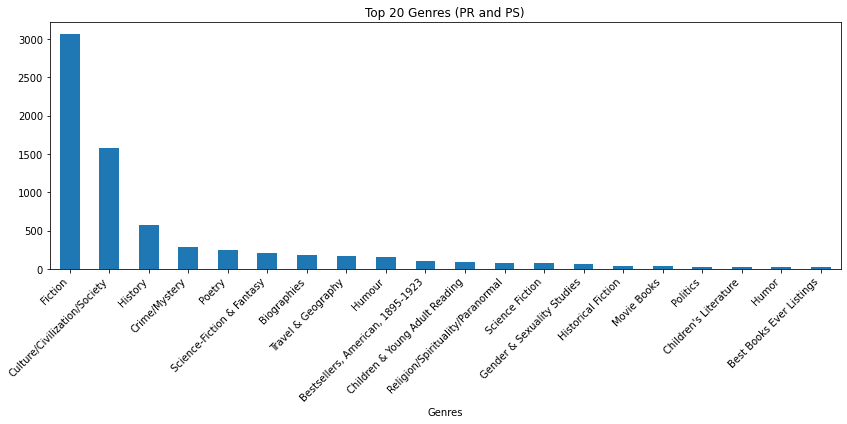

In [96]:
ax = df_usuk["Genres"].explode().value_counts().iloc[1:].head(20).plot( # we don't include the top value which is 'literature' (already expected)
    kind="bar", figsize=(12,6), title="Top 20 Genres (PR and PS)"
)

ax.tick_params(axis="x", rotation=45)
plt.xticks(ha="right")
plt.tight_layout()

In [97]:
df_usuk["Genres"].explode().value_counts()

Genres
Literature                                                 3428
Fiction                                                    3062
Culture/Civilization/Society                               1576
History                                                     575
Crime/Mystery                                               286
Poetry                                                      246
Science-Fiction & Fantasy                                   212
Biographies                                                 182
Travel & Geography                                          170
Humour                                                      162
Bestsellers, American, 1895-1923                             99
Children & Young Adult Reading                               91
Religion/Spirituality/Paranormal                             76
Science Fiction                                              75
Gender & Sexuality Studies                                   60
Historical Fiction               

3062 (80%) out of 3834 books are fiction!
Let's see the coverage of the top genres

In [100]:
# Pre-compute inverted index: genre -> set of book indices
genre_sets = df_usuk["Genres"].dropna()
genre_to_books = {}
for idx, genres in genre_sets.items():
    for g in genres:
        genre_to_books.setdefault(g, set()).add(idx)

# Pre-sort genres by coverage size (descending) — greedy starts from most frequent
sorted_genres = sorted(genre_to_books.items(), key=lambda x: len(x[1]), reverse=True)

# Greedy set cover
all_books = set(genre_sets.index)
covered = set()
selected_genres = []

for genre, books in sorted_genres:
    new_coverage = books - covered
    if new_coverage:  # only add if it covers something new
        selected_genres.append((genre, len(new_coverage)))
        covered |= new_coverage
    if covered == all_books:
        break  # early exit once 100% covered

result_df = pd.DataFrame(selected_genres, columns=['Genre', 'New books covered'])
result_df['Cumulative covered'] = result_df['New books covered'].cumsum()
result_df['Pct covered'] = result_df['Cumulative covered'] / len(all_books) * 100
result_df

,Genre,New books covered,Cumulative covered,Pct covered
0,Literature,3428,3428,89.410537
1,Fiction,347,3775,98.461137
2,Culture/Civilization/Society,21,3796,99.008868
3,History,8,3804,99.217527
4,Poetry,10,3814,99.478352
5,Science-Fiction & Fantasy,1,3815,99.504434
6,Biographies,2,3817,99.556599
7,Travel & Geography,1,3818,99.582681
8,Humour,1,3819,99.608764
9,Religion/Spirituality/Paranormal,2,3821,99.660929


(The above means books with genre 'Literature' covers 89.41% of the set, then adding genre "Fiction" to that increase the coverage to 98.46%, and further addition is quite negligible in terms of gain)

All of these genres seem quite relevant - so we can be quite confident with our data now :)

In [102]:
# Drop Bookshelves and Subjects because we already extracted Genres and Themes
df_usuk = df_usuk.drop(columns=['Bookshelves', 'Subjects'])

In [104]:
# Save the extracted data 
# With csv for quick look
output_csv = "../data/GP_1750_2000_opium_filtered.csv"
df_usuk.to_csv(output_csv, index=False)
# With parquet for preserving structure like list/array columns
output_parquet = "../data/GP_1750_2000_opium_filtered.parquet"
df_usuk.to_parquet(output_parquet, index=False)